In [1]:
!pip install ta --upgrade
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

In [2]:
LOOK_BACK   = 21
K_FOLDS     = 5
EPOCHS      = 200
BATCH_SIZE  = 64
PATIENCE    = 15

FEATURES = [
    'ZScore', 'SMA_20', 'EMA_50',
    'FFTEnergy', 'DateEncoded', 'VPT'
]
TARGET = ['High', 'Low']

HYPERPARAMS = {
    'units_0':        736,
    'dropout_rate_0': 0.04467657940147216,
    'learning_rate':  0.0003433353124094906,
}

In [3]:
def check_nan(df: pd.DataFrame, stage: str, features: list):
    nan_counts = df[features].isna().sum()
    total_nan  = nan_counts.sum()
    if total_nan > 0:
        print(f"\n[NaN CHECK — {stage}]")
        print(nan_counts[nan_counts > 0].to_string())
        print(f"  Total NaN cells : {total_nan}")
    else:
        print(f"[NaN CHECK — {stage}] No NaNs found")


def clean_dataframe(df: pd.DataFrame, features: list) -> pd.DataFrame:
    df = df.replace([np.inf, -np.inf], np.nan)

    df[features] = df[features].ffill()

    df[features] = df[features].bfill()

    df[features] = df[features].fillna(df[features].median()).fillna(0)

    return df


def load_and_engineer(path: str) -> pd.DataFrame:
    from ta.trend import SMAIndicator, EMAIndicator
    from scipy.fftpack import fft

    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)

    df['DateEncoded'] = (df['Date'] - df['Date'].min()).dt.days

    df['SMA_20'] = SMAIndicator(close=df['Close'], window=20).sma_indicator()
    df['EMA_50'] = EMAIndicator(close=df['Close'], window=50).ema_indicator()

    df['VPT'] = (df['Close'].pct_change() * df['Shares Traded']).cumsum()

    def fft_energy(series):
        arr = np.asarray(series)
        return np.sum(np.abs(fft(arr)) ** 2)

    df['FFTEnergy'] = df['Close'].rolling(window=50).apply(fft_energy, raw=False)

    df['ZScore'] = 0.0

    df.dropna(subset=['SMA_20', 'EMA_50', 'FFTEnergy'], inplace=True)
    df.reset_index(drop=True, inplace=True)

    base_features = ['DateEncoded', 'SMA_20', 'EMA_50', 'VPT', 'FFTEnergy', 'ZScore']
    df = clean_dataframe(df, base_features)

    check_nan(df, 'After load_and_engineer', base_features)

    return df


def add_zscore(train_df: pd.DataFrame,
               test_df:  pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_mean = train_df['Close'].mean()
    train_std  = train_df['Close'].std()

    train_df = train_df.copy()
    test_df  = test_df.copy()

    train_df['ZScore'] = (train_df['Close'] - train_mean) / train_std
    test_df['ZScore']  = (test_df['Close']  - train_mean) / train_std

    return train_df, test_df


In [4]:
def scale_data(train_df: pd.DataFrame,
               test_df:  pd.DataFrame,
               features: list,
               target:   list):
    train_df = clean_dataframe(train_df.copy(), features)
    test_df  = clean_dataframe(test_df.copy(),  features)

    check_nan(train_df, 'scale_data → train', features)
    check_nan(test_df,  'scale_data → test',  features)

    feat_std_scaler  = StandardScaler()
    feat_norm_scaler = MinMaxScaler()
    tgt_std_scaler   = StandardScaler()
    tgt_norm_scaler  = MinMaxScaler()

    train_feat_std  = feat_std_scaler.fit_transform(train_df[features])
    test_feat_std   = feat_std_scaler.transform(test_df[features])

    train_feat_norm = feat_norm_scaler.fit_transform(train_feat_std)
    test_feat_norm  = feat_norm_scaler.transform(test_feat_std)

    train_scaled = train_df.copy()
    test_scaled  = test_df.copy()

    train_scaled[features] = train_feat_norm
    test_scaled[features]  = test_feat_norm

    y_train_std  = tgt_std_scaler.fit_transform(train_df[target])
    y_test_std   = tgt_std_scaler.transform(test_df[target])

    y_train_norm = tgt_norm_scaler.fit_transform(y_train_std)
    y_test_norm  = tgt_norm_scaler.transform(y_test_std)

    y_train_scaled = train_df.copy()
    y_test_scaled  = test_df.copy()

    y_train_scaled[target] = y_train_norm
    y_test_scaled[target]  = y_test_norm

    scalers = {
        'feat_std':  feat_std_scaler,
        'feat_norm': feat_norm_scaler,
        'tgt_std':   tgt_std_scaler,
        'tgt_norm':  tgt_norm_scaler,
    }

    return train_scaled, test_scaled, y_train_scaled, y_test_scaled, scalers


def create_sequences(data:      pd.DataFrame,
                     y_scaled:  pd.DataFrame,
                     features:  list,
                     target:    list,
                     look_back: int):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data.iloc[i : i + look_back][features].values.astype('float32'))
        y.append(y_scaled.iloc[i + look_back][target].values.astype('float32'))
    return np.array(X), np.array(y)



def build_model(input_shape: tuple, hyperparams: dict) -> tf.keras.Model:
    model = Sequential([
        Input(shape=input_shape),
        GRU(units=hyperparams['units_0'], return_sequences=False),
        Dropout(hyperparams['dropout_rate_0']),
        Dense(2, activation='linear'),
    ])
    model.compile(
        optimizer=Adam(learning_rate=hyperparams['learning_rate']),
        loss='mse'
    )
    return model


def train_model(model:            tf.keras.Model,
                X_train:          np.ndarray,
                y_train:          np.ndarray,
                epochs:           int,
                batch_size:       int,
                patience:         int) -> tf.keras.Model:

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )

    model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )
    return model


def inverse_transform(arr: np.ndarray, scalers: dict) -> np.ndarray:
    arr_std  = scalers['tgt_norm'].inverse_transform(arr)
    arr_orig = scalers['tgt_std'].inverse_transform(arr_std)
    return arr_orig


def run_timeseries_cv(df:         pd.DataFrame,
                      features:   list,
                      target:     list,
                      look_back:  int,
                      hyperparams: dict,
                      k:          int = K_FOLDS):

    tscv = TimeSeriesSplit(n_splits=k)

    fold_rmse, fold_mae = [], []
    all_actuals, all_predictions = [], []
    final_model, final_scalers = None, None

    for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
        print(f"\n{'='*50}")
        print(f"  Fold {fold + 1} / {k}")
        print(f"  Train rows: {len(train_idx)} | Test rows: {len(test_idx)}")
        print(f"{'='*50}")

        train_raw = df.iloc[train_idx].copy()
        test_raw  = df.iloc[test_idx].copy()

        train_raw, test_raw = add_zscore(train_raw, test_raw)

        train_scaled, test_scaled, y_train_s, y_test_s, scalers = scale_data(
            train_raw, test_raw, features, target
        )

        X_train, y_train_seq = create_sequences(train_scaled, y_train_s, features, target, look_back)
        X_test,  y_test_seq  = create_sequences(test_scaled,  y_test_s,  features, target, look_back)

        if len(X_train) == 0 or len(X_test) == 0:
            print(f"  Fold {fold+1} skipped — not enough data for sequences.")
            continue

        model = build_model(
            input_shape=(X_train.shape[1], X_train.shape[2]),
            hyperparams=hyperparams
        )
        model = train_model(model, X_train, y_train_seq, EPOCHS, BATCH_SIZE, PATIENCE)

        preds_scaled = model.predict(X_test, verbose=0)
        preds        = inverse_transform(preds_scaled, scalers)
        actuals      = inverse_transform(y_test_seq,   scalers)

        rmse = np.sqrt(mean_squared_error(actuals, preds))
        mae  = mean_absolute_error(actuals, preds)

        fold_rmse.append(rmse)
        fold_mae.append(mae)

        print(f"\n  Fold {fold+1} Results  →  RMSE: {rmse:.2f}  |  MAE: {mae:.2f}")

        all_actuals.extend(actuals.flatten())
        all_predictions.extend(preds.flatten())

        final_model   = model
        final_scalers = scalers

    print(f"\n{'='*50}")
    print("  FINAL CROSS-VALIDATION RESULTS")
    print(f"  Average RMSE : {np.mean(fold_rmse):.2f}")
    print(f"  Average MAE  : {np.mean(fold_mae):.2f}")
    print(f"{'='*50}\n")

    plt.figure(figsize=(14, 5))
    plt.plot(all_actuals,     label='Actual',    alpha=0.7)
    plt.plot(all_predictions, label='Predicted', alpha=0.7)
    plt.title('Actual vs Predicted  —  All Folds (TimeSeriesSplit)')
    plt.xlabel('Sample')
    plt.ylabel('Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return final_model, final_scalers



def predict_next_day(model:    tf.keras.Model,
                     df:       pd.DataFrame,
                     features: list,
                     scalers:  dict,
                     look_back: int) -> dict:
    last_rows = df.iloc[-look_back:].copy()

    feat_std  = scalers['feat_std'].transform(last_rows[features])
    feat_norm = scalers['feat_norm'].transform(feat_std)

    X_input = feat_norm.reshape(1, look_back, len(features)).astype('float32')

    pred_scaled = model.predict(X_input, verbose=0)
    pred        = inverse_transform(pred_scaled, scalers)

    return {
        'Predicted High': round(float(pred[0][0]), 2),
        'Predicted Low':  round(float(pred[0][1]), 2),
    }


Loading data and engineering features...
[NaN CHECK — After load_and_engineer] No NaNs found
Dataset shape after feature engineering: (4844, 13)
[NaN CHECK — scale_data → train] No NaNs found
[NaN CHECK — scale_data → test] No NaNs found

X_train: (3854, 21, 6) | X_test: (948, 21, 6)

Training final model on 80% split...
Epoch 1/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0057 - val_loss: 0.0031
Epoch 2/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.2447e-04 - val_loss: 0.0025
Epoch 3/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5852e-04 - val_loss: 0.0020
Epoch 4/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3269e-04 - val_loss: 0.0016
Epoch 5/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0423e-04 - val_loss: 0.0015
Epoch 6/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7582e-04 - val_loss: 9.3443e-04
Epoch 7/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7050e-04 - val_loss: 9.5884e-04
Epoch 8/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 1

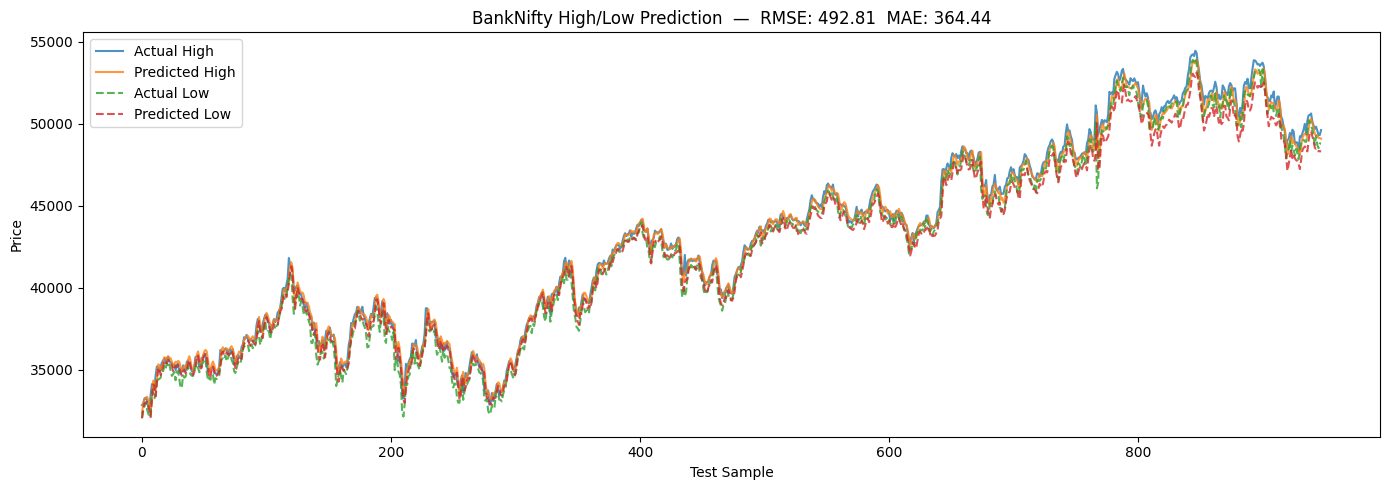


Model saved to 'banknifty_gru_fixed.keras'

Next Day Prediction:
  Predicted High : 49402.23
  Predicted Low  : 48653.33


In [5]:
print("Loading data and engineering features...")
df = load_and_engineer('Banknifty_index.csv')
print(f"Dataset shape after feature engineering: {df.shape}")

split      = int(len(df) * 0.8)
train_raw  = df.iloc[:split].copy()
test_raw   = df.iloc[split:].copy()

train_raw, test_raw = add_zscore(train_raw, test_raw)

train_scaled, test_scaled, y_train_s, y_test_s, scalers = scale_data(
  train_raw, test_raw, FEATURES, TARGET
)

X_train, y_train_seq = create_sequences(train_scaled, y_train_s, FEATURES, TARGET, LOOK_BACK)
X_test,  y_test_seq  = create_sequences(test_scaled,  y_test_s,  FEATURES, TARGET, LOOK_BACK)

print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")

print("\nTraining final model on 80% split...")
model = build_model(
  input_shape=(X_train.shape[1], X_train.shape[2]),
  hyperparams=HYPERPARAMS
)
model = train_model(model, X_train, y_train_seq, EPOCHS, BATCH_SIZE, PATIENCE)

preds_scaled = model.predict(X_test, verbose=0)
preds        = inverse_transform(preds_scaled, scalers)
actuals      = inverse_transform(y_test_seq,   scalers)

rmse = np.sqrt(mean_squared_error(actuals, preds))
mae  = mean_absolute_error(actuals, preds)

print(f"\nTest RMSE : {rmse:.2f}")
print(f"Test MAE  : {mae:.2f}")

plt.figure(figsize=(14, 5))
plt.plot(actuals[:, 0],     label='Actual High',    alpha=0.8)
plt.plot(preds[:, 0],       label='Predicted High', alpha=0.8)
plt.plot(actuals[:, 1],     label='Actual Low',     alpha=0.8, linestyle='--')
plt.plot(preds[:, 1],       label='Predicted Low',  alpha=0.8, linestyle='--')
plt.title(f'BankNifty High/Low Prediction  —  RMSE: {rmse:.2f}  MAE: {mae:.2f}')
plt.xlabel('Test Sample')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

model.save('banknifty_gru_fixed.keras')
print("\nModel saved to 'banknifty_gru_fixed.keras'")

train_mean = train_raw['Close'].mean()
train_std  = train_raw['Close'].std()
df['ZScore'] = (df['Close'] - train_mean) / train_std

next_day = predict_next_day(model, df, FEATURES, scalers, LOOK_BACK)
print(f"\nNext Day Prediction:")
print(f"  Predicted High : {next_day['Predicted High']}")
print(f"  Predicted Low  : {next_day['Predicted Low']}")